In [1]:
# ambiente anaconda
import sys
print(sys.executable) # orange3 ou youtube
import sys
print(sys.version)

/home/fabiene/anaconda3/envs/orange3/bin/python
3.10.18 (main, Jun  5 2025, 13:14:17) [GCC 11.2.0]


# Projeto 17: Compactação de imagens com Deep Autoencoders

## Etapa 1: Importação das bibliotecas

adicionar mais camadas ocultas

In [2]:
from torchvision import datasets, transforms
import torch
from torch import nn, optim
import matplotlib.pyplot as plt
torch.__version__

'2.9.1+cpu'

In [3]:
torch.manual_seed(123) # semente, mesmo valor sempre para reproduzir

## Etapa 2: Base de dados

In [4]:
# 1. Baixando e preparando o conjunto de dados (Dataset):
# 'MNIST-data_compacto': Nome da pasta onde as imagens serão salvas.
# train = True: Indica que queremos as 60.000 imagens de TREINO (não as de teste).
# download = True: Se os arquivos não estiverem na pasta, o PyTorch baixa da internet.
# transform = ToTensor(): Converte as imagens (que são arquivos de imagem comuns) 
# em Tensores (matrizes numéricas) e escala os pixels de 0-255 para 0-1.
dataset_train = datasets.MNIST('MNIST-data_compacto', train = True, download = True,
                               transform = transforms.ToTensor())

# 2. Configurando o carregador de dados (DataLoader):
# dataset_train: A fonte dos dados que acabamos de definir.
# batch_size = 256: Em vez de entregar uma imagem por vez (muito lento) ou todas de 
# uma vez (pesado), ele entrega "pacotes" de 256 imagens por rodada.
# shuffle = True: Embaralha as imagens a cada época. Isso é vital para que a rede 
# não aprenda a "ordem" das imagens, mas sim o conteúdo delas.
loader_train = torch.utils.data.DataLoader(dataset_train, batch_size = 256,
                                           shuffle = True)

In [5]:
# 1. Preparando o Conjunto de Validação (Teste):
# train = False: Este é o comando chave. Ele baixa as 10.000 imagens que NÃO 
# estão no conjunto de treino. O modelo nunca verá essas imagens durante o aprendizado.
# transform = transforms.ToTensor(): Garante que essas novas imagens tenham o mesmo 
# formato (0 a 1) e escala que as imagens de treino.
dataset_val = datasets.MNIST('MNIST-data_compacto', train = False, download = True,
                             transform = transforms.ToTensor())

# 2. Configurando o Carregador de Validação:
# loader_val: Cria a esteira que entregará essas 10.000 imagens para teste.
# batch_size = 256: Mantemos o mesmo tamanho de pacote para manter a consistência.
# shuffle = True: Embora não seja obrigatório na validação (pois o modelo não está 
# aprendendo), embaralhar ajuda a ter uma visão imparcial do erro a cada lote.
loader_val = torch.utils.data.DataLoader(dataset_val, batch_size = 256,
                                         shuffle = True)

## Etapa 3: Construção do autoencoder

In [6]:
# A lógica aqui é o "Efeito Ampulheta": 
# 784 (Entrada) -> 128 -> 64 -> 32 (Gargalo/Resumo Aonde esta a imagem codificada) -> (voltando) 64 -> 128 -> 784 (Saída)
# 784 -> 128 -> 64 -> 32 -> 64 -> 128 -> 784

class autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        # Camadas do encoder
        # --- CAMADAS DO ENCODER (Compactação) ---
        # Comprime a imagem de 784 pixels para 128 características
        self.encoder0 = nn.Linear(in_features = 784, out_features = 128)
        # Comprime de 128 para 64 características
        self.encoder1 = nn.Linear(128, 64)
        # Comprime de 64 para 32 (O ponto de compressão máxima: o código latente)
        self.encoder2 = nn.Linear(64, 32)
        
        # Camadas do decoder (processo inverso para reproduzir a imagem)
        # --- CAMADAS DO DECODER (Reconstrução) ---
        # Começa a expandir: de 32 de volta para 64
        self.decoder0 = nn.Linear(32, 64)
        # Expande de 64 para 128
        self.decoder1 = nn.Linear(64, 128)
        # Expande de 128 de volta para os 784 pixels originais
        self.decoder2 = nn.Linear(128, 784)
        
        # Camadas de ativação
        # --- FUNÇÕES DE ATIVAÇÃO ---
        self.activation0 = nn.ReLU()    # Usada nas camadas internas para aprender padrões (usa nas camadas do meio)
        self.activation1 = nn.Sigmoid() # Usada na última camada para garantir pixels entre 0 e 1

    def forward(self, X):
        # Estrutura do encoder
        # FLUXO DO ENCODER: Passa pelas camadas lineares e aplica ReLU em cada uma
        # ligações nas encoders e camadas lineares
        X = self.activation0(self.encoder0(X))
        X = self.activation0(self.encoder1(X))
        X = self.activation0(self.encoder2(X)) # Aqui X vira apenas 32 números
        
        # Estrutura do decoder
        # FLUXO DO DECODER: Reconstrói a imagem a partir dos 32 números
        X = self.activation0(self.decoder0(X))
        X = self.activation0(self.decoder1(X))
        # Aplica SIGMOID na última camada para a saída ser comparável à imagem original
        X = self.activation1(self.decoder2(X))
        return X

$\begin{array}{|c|c|c|c|}
\hline
\textbf{Função} & \textbf{Fórmula} & \textbf{Intervalo de saída} & \textbf{Uso comum} \\
\hline
\text{Sigmoid} & 
\sigma(x) = \frac{1}{1 + e^{-x}} & (0, 1) & \text{Classificação binária} \\
\hline
\text{Tanh} & 
\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}} & (-1, 1) & \text{Camadas ocultas (alternativa ao ReLU)} \\
\hline
\text{ReLU} & 
f(x) = \max(0, x) & [0, \infty) & \text{Camadas ocultas (mais usado)} \\
\hline
\text{Leaky ReLU} & 
f(x) = \begin{cases}
x & \text{se } x > 0 \\
\alpha x & \text{se } x \leq 0
\end{cases} & (-\infty, \infty) & \text{Evita neurônios mortos no ReLU} \\
\hline
\text{ELU} & 
f(x) = \begin{cases}
x & \text{se } x > 0 \\
\alpha(e^x - 1) & \text{se } x \leq 0
\end{cases} & (-\alpha, \infty) & \text{Camadas ocultas, alternativa ao ReLU} \\
\hline
\text{Softmax} & 
f(x_i) = \frac{e^{x_i}}{\sum_j e^{x_j}} & (0, 1), \ \sum f(x_i) = 1 & \text{Classificação multiclasse} \\
\hline
\end{array}$

# 🔹 O ReLU (Rectified Linear Unit)

Características:

Simples, rápido de calcular.

Resolve o problema do vanishing gradient (quando os gradientes ficam quase zero em sigmoides/tanh).

Muito usado em camadas ocultas.

⚠️ Problema: pode causar “neurônios mortos” (quando muitos valores ficam ≤ 0 e nunca mais reativam).


# 🔹 1. Sigmoid

Saída entre 0 e 1 → ideal para classificação binária.

Problema: saturação → gradientes muito pequenos para valores extremos.

# 🔹 2. Tanh (Tangente Hiperbólica)

Saída entre -1 e 1.

Centraliza os dados em torno de 0 (melhor que sigmoid).

Mas ainda sofre com vanishing gradient.

# 🔹 3. Leaky ReLU

Variante do ReLU que deixa um “vazamento” para valores negativos.

Resolve o problema de neurônios mortos.

#🔹 4. ELU (Exponential Linear Unit)

Parecido com ReLU, mas valores negativos seguem uma curva exponencial suave.
Melhora a aprendizagem, mas é mais caro computacionalmente.

#🔹 5. Softmax

Transforma um vetor de valores em probabilidades que somam 1.

Usado em classificação multiclasse (saída com várias categorias).



🔹 Resumo, o uso mais comum:

Camadas ocultas → ReLU, Leaky ReLU, às vezes Tanh/ELU.

Saída binária → Sigmoid.

Saída multiclasse → Softmax.



### valores numéricos de séries temporais (ex: vendas, demanda, preços), o ideal é:

- ReLU nas camadas ocultas

- Linear (sem ativação) na saída.

### valores numéricos de séries temporais (ex: vendas, demanda, preços), o ideal é:

- ReLU nas camadas ocultas

- Linear (sem ativação) na saída.

Essa sequência de números (32, 64, 128) não é aleatória. Ela segue uma lógica baseada em arquitetura de computadores, eficiência matemática e na própria estratégia de aprendizado da rede neural.


1. A Lógica Binária (Potências de 2)Computadores e, principalmente, as GPUs (unidades de processamento gráfico) são construídas para processar dados em blocos de potências de 2 ($2^5=32$, $2^6=64$, $2^7=128$).

O que faz: Ao usar esses números, você alinha os dados com a memória do hardware.

Resultado: O processamento é muito mais rápido do que se você usasse números "quebrados" como 37, 51 ou 113, pois não sobra espaço vazio nos blocos de processamento da placa de vídeo.

2. O Efeito Funil (Hierarquia de Características)
A rede neural precisa aprender do "geral" para o "específico". No seu Autoencoder, você está fazendo um funil:

784 para 128: A rede reduz os pixels, mas ainda mantém muita informação espacial.

128 para 64: Ela começa a identificar padrões maiores, como círculos ou retas.

64 para 32: Ela chega no "DNA" do número. É o resumo do resumo.


3. Teorema da Amostragem e Compressão
Imagine que você está resumindo um livro:

Se você resumir um capítulo de 100 páginas para 50 (128), ainda tem muitos detalhes.

Se resumir para 10 páginas (64), você tem os eventos principais.

Se resumir para 1 parágrafo (32), você tem apenas a ideia central.

Se você passasse de 784 direto para 32, a rede teria um "choque" de informação e perderia detalhes cruciais. Usar as camadas intermediárias (128 e 64) permite que a rede distile a informação suavemente.


4. Capacidade de Memorização (Vulnerabilidade)
Neurônios demais: Se você usasse 500 neurônios no meio, a rede ficaria "preguiçosa" e apenas copiaria os pixels da entrada para a saída sem aprender a essência.

Neurônios de menos: Se usasse apenas 2, a rede não teria capacidade matemática para diferenciar um "8" de um "0".

32, 64 e 128 são valores que, historicamente, funcionam muito bem para imagens simples como as do MNIST (28x28 pixels), oferecendo capacidade suficiente sem causar lentidão.


Curiosidade: Eu posso usar outros números?
Sim! Você poderia usar 100, 50 e 25. O modelo ainda funcionaria, mas você perderia aquela pequena vantagem de velocidade das GPUs e, talvez, a reconstrução da imagem ficasse um pouco mais "suja".

Quer tentar mudar esses valores para ver como a "nitidez" da imagem reconstruída muda? Podemos testar uma versão com o dobro de neurônios (256, 128, 64) para ver se os números ficam mais bonitos!

In [7]:
# 1. torch.cuda.is_available(): Pergunta ao computador: "Ei, você tem uma placa de 
# vídeo da NVIDIA instalada e os drivers (CUDA) estão prontos para uso?"
# 
# 2. torch.device('cuda'): Se a resposta for SIM, o PyTorch reserva a GPU para 
# processar os cálculos. A GPU é centenas de vezes mais rápida para redes neurais.
# 
# 3. else torch.device('cpu'): Se a resposta for NÃO, ele usa o processador (CPU) 
# comum. O código vai funcionar, mas o treinamento será muito mais lento.
# 
# 4. device: Armazena essa decisão na variável para que você possa usar depois em 
# .to(device) para enviar seus modelos e dados para lá.
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

# Exibe qual foi a decisão (no Google Colab com GPU ativada, aparecerá 'cuda')
device

device(type='cpu')

In [8]:
# 1. Instanciação do Modelo:
# model = autoencoder(): Aqui você está criando o objeto real a partir da 
# classe que desenhamos antes. É o momento em que todos aqueles neurônios 
# (784, 128, 64, 32...) e pesos aleatórios são criados na memória.
model = autoencoder()

# 2. Transferência de Memória:
# .to(device): Pega toda a estrutura da rede neural e a envia para o 
# hardware escolhido (GPU ou CPU). Sem isso, o modelo ficaria na CPU 
# por padrão, e se seus dados estivessem na GPU, o código daria erro 
# por não conseguir "conversar" entre memórias diferentes.
model.to(device)

autoencoder(
  (encoder0): Linear(in_features=784, out_features=128, bias=True)
  (encoder1): Linear(in_features=128, out_features=64, bias=True)
  (encoder2): Linear(in_features=64, out_features=32, bias=True)
  (decoder0): Linear(in_features=32, out_features=64, bias=True)
  (decoder1): Linear(in_features=64, out_features=128, bias=True)
  (decoder2): Linear(in_features=128, out_features=784, bias=True)
  (activation0): ReLU()
  (activation1): Sigmoid()
)

In [9]:
# 1. Definindo a Função de Perda (Criterion):
# nn.BCELoss(): Abreviação para "Binary Cross Entropy Loss". 
# No Autoencoder, comparamos cada pixel da imagem original com o pixel reconstruído.
# Como nossos pixels estão entre 0 e 1 (devido ao ToTensor e à Sigmoid final),
# essa função mede a "distância" entre a imagem real e a cópia.
# Quanto menor esse valor, mais parecida a cópia está da original.
criterion = nn.BCELoss()

# 2. Definindo o Otimizador:
# optim.Adam: É o "cérebro" que ajusta os pesos da rede. O Adam é um dos mais 
# populares porque é rápido e se ajusta automaticamente durante o treino.
# model.parameters(): Diz ao Adam quais são os pesos e conexões que ele 
# tem permissão para alterar dentro do seu autoencoder.
optimizer = optim.Adam(model.parameters())

🔍Por que esses dois?

Por que BCELoss? Embora o nome "Binário" pareça estranho para imagens, ele funciona muito bem para o MNIST porque as imagens são basicamente fundo preto (0) e traço branco (1). Ele trata cada pixel como uma probabilidade de ser "aceso" ou "apagado".

Por que Adam? Imagine que a rede está em uma montanha russa no escuro tentando achar o ponto mais baixo (o menor erro). O Adam usa o "momento" (como uma bola ganhando velocidade na descida) para chegar lá mais rápido, sem ficar preso em pequenos buracos no caminho.

💡 O que aconteceria se não tivéssemos isso?
Sem o Criterion, o modelo não saberia se a imagem que ele criou parece um "4" ou apenas um borrão cinza.

Sem o Optimizer, o modelo saberia que errou, mas não saberia o que mudar nas conexões internas para não errar de novo.

## Etapa 4: Treinamento do modelo

In [10]:
28*28

784

In [11]:
# Listas para guardar o histórico de erros
historico_loss_train = []
historico_loss_val = []

# Inicia o ciclo de 20 épocas (20 passagens completas pelo dataset)
for epoch in range(20):
    running_loss_train = 0.
    
    # --- FASE DE TREINAMENTO ---
    for data in loader_train:
        model.train()              # Ativa o modo de treino (ajusta pesos)
        inputs, _ = data           # Carrega imagens; o '_' ignora as etiquetas (0-9)
        inputs = inputs.to(device) # Envia para GPU/CPU
        inputs = inputs.view(-1, 28*28)       
        #inputs = inputs.view(-1, 784) # Estica a imagem 28x28 em uma linha de 784

        optimizer.zero_grad()      # Zera os cálculos de erro da rodada anterior

        # --- O DESAFIO DO AUTOENCODER ---
        outputs = model(inputs)    # Tenta reconstruir a imagem a partir do "funil"
        
        # Compara a imagem reconstruída (outputs) com a original (inputs)
        # O objetivo é que elas sejam idênticas!
        loss = criterion(outputs, inputs.view(*outputs.shape))
        
        loss.backward()            # Calcula o que precisa mudar para diminuir o erro
        optimizer.step()           # Aplica as mudanças nos pesos do modelo

        running_loss_train += loss.item()
        
    # Validação
    # --- FASE DE VALIDAÇÃO (Teste de qualidade) ---
    running_loss_val = 0.
    for data in loader_val:
        model.eval()               # Modo de avaliação (apenas observa, não aprende)
        inputs, _ = data
        inputs = inputs.to(device)
        inputs = inputs.view(-1, 28*28)
        #inputs = inputs.view(-1, 784)
        
        outputs = model(inputs)    # Reconstrói imagens que nunca viu antes
        
        # Mede o erro na validação
        loss = criterion(outputs, inputs.view(*outputs.shape))
        running_loss_val += loss.item()
        
    # Final da época
    # Exibe o progresso: se perda_train e perda_val estiverem caindo, a IA está aprendendo!
    print('ÉPOCA {:3d}: perda_train {:.5f} perda_val {:.5f}'.format(
          epoch + 1, 
          running_loss_train/len(loader_train), 
          running_loss_val/len(loader_val)))
    # Salva as médias da época nas listas
    historico_loss_train.append(running_loss_train/len(loader_train))
    historico_loss_val.append(running_loss_val/len(loader_val))

ÉPOCA   1: perda_train 0.29516 perda_val 0.23521
ÉPOCA   2: perda_train 0.20553 perda_val 0.17358
ÉPOCA   3: perda_train 0.16007 perda_val 0.15014
ÉPOCA   4: perda_train 0.14689 perda_val 0.14191
ÉPOCA   5: perda_train 0.14099 perda_val 0.13693
ÉPOCA   6: perda_train 0.13549 perda_val 0.13200
ÉPOCA   7: perda_train 0.13100 perda_val 0.12795
ÉPOCA   8: perda_train 0.12746 perda_val 0.12499
ÉPOCA   9: perda_train 0.12413 perda_val 0.12146
ÉPOCA  10: perda_train 0.12106 perda_val 0.11872
ÉPOCA  11: perda_train 0.11815 perda_val 0.11563
ÉPOCA  12: perda_train 0.11594 perda_val 0.11393
ÉPOCA  13: perda_train 0.11421 perda_val 0.11215
ÉPOCA  14: perda_train 0.11274 perda_val 0.11090
ÉPOCA  15: perda_train 0.11133 perda_val 0.11015
ÉPOCA  16: perda_train 0.10997 perda_val 0.10809
ÉPOCA  17: perda_train 0.10854 perda_val 0.10678
ÉPOCA  18: perda_train 0.10715 perda_val 0.10607
ÉPOCA  19: perda_train 0.10597 perda_val 0.10442
ÉPOCA  20: perda_train 0.10487 perda_val 0.10305


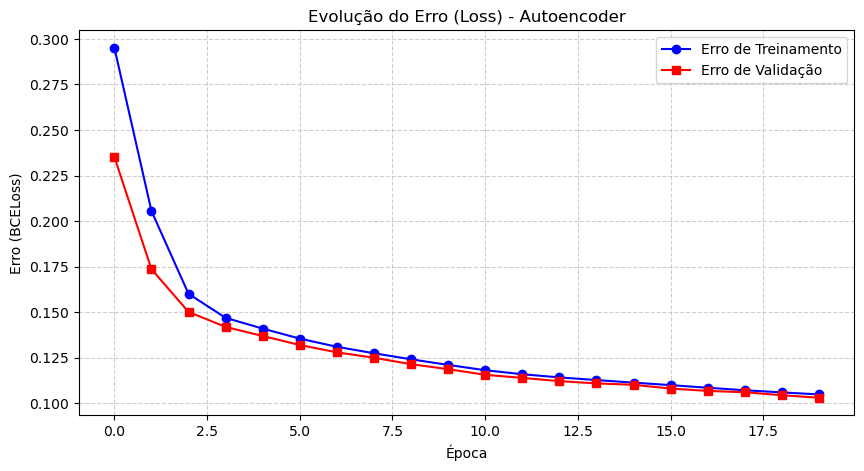

In [12]:
import matplotlib.pyplot as plt

# Configura o tamanho e o estilo do gráfico
plt.figure(figsize=(10, 5))
plt.plot(historico_loss_train, label='Erro de Treinamento', color='blue', marker='o')
plt.plot(historico_loss_val, label='Erro de Validação', color='red', marker='s')

# Detalhes visuais
plt.title('Evolução do Erro (Loss) - Autoencoder')
plt.xlabel('Época')
plt.ylabel('Erro (BCELoss)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Exibe o gráfico
plt.show()


🔍 O que observar no gráfico?

Curvas Descendo: Se ambas as linhas estão caindo e se aproximando do zero, seu Autoencoder está aprendendo a reconstruir as imagens com perfeição.

A "Diferença" (Gap): Se a linha azul (treino) continuar descendo muito e a vermelha (validação) começar a subir ou estabilizar, seu modelo está "decorando" (overfitting).

Estabilidade: Se as curvas ficarem "flat" (planas) antes da época 20, significa que o modelo já aprendeu tudo o que podia e você não precisaria de mais épocas.



## Etapa 5: Geração do encoder

In [14]:
list(model.children())

[Linear(in_features=784, out_features=128, bias=True),
 Linear(in_features=128, out_features=64, bias=True),
 Linear(in_features=64, out_features=32, bias=True),
 Linear(in_features=32, out_features=64, bias=True),
 Linear(in_features=64, out_features=128, bias=True),
 Linear(in_features=128, out_features=784, bias=True),
 ReLU(),
 Sigmoid()]

In [15]:
list(model.children())[6]

ReLU()

In [16]:
# list(model.children()):
# 1. model.children(): É um "iterador" que percorre todas as camadas principais 
# definidas dentro do seu __init__. 
# No seu caso, ele vai listar: encoder0, encoder1, encoder2, decoder0, etc.
# 
# 2. list(...): Transforma esse iterador em uma lista comum do Python.
# Isso permite que você acesse camadas específicas pelo índice, como:
# list(model.children())[0] para pegar apenas a primeira camada (encoder0).
list(model.children())

[Linear(in_features=784, out_features=128, bias=True),
 Linear(in_features=128, out_features=64, bias=True),
 Linear(in_features=64, out_features=32, bias=True),
 Linear(in_features=32, out_features=64, bias=True),
 Linear(in_features=64, out_features=128, bias=True),
 Linear(in_features=128, out_features=784, bias=True),
 ReLU(),
 Sigmoid()]

In [17]:
# Esta nova classe serve exclusivamente para COMPRIMIR a imagem.
# Ela ignora o Decoder e foca apenas em transformar 784 pixels em 32 números.

class encoder(nn.Module):
    def __init__(self):
        super().__init__()
        
        # Aqui fazemos a extração das camadas do modelo 'model' (o Autoencoder treinado):
        # list(model.children())[0] -> Pega a 1ª camada (Linear 784 -> 128)
        self.encoder0 = list(model.children())[0]
        
        # list(model.children())[1] -> Pega a 2ª camada (Linear 128 -> 64)
        self.encoder1 = list(model.children())[1]
        
        # list(model.children())[2] -> Pega a 3ª camada (Linear 64 -> 32)
        # Este é o ponto onde a informação está no tamanho mínimo (o "gargalo")
        self.encoder2 = list(model.children())[2]
        
        # list(model.children())[6] -> Pega a função de ativação ReLU que estava 
        # guardada na 7ª posição da lista de componentes do modelo original.
        self.activation0 = list(model.children())[6]

    def forward(self, X):
        # O fluxo de dados agora para exatamente nos 32 neurônios:
        X = self.activation0(self.encoder0(X))
        X = self.activation0(self.encoder1(X))
        X = self.activation0(self.encoder2(X))
        
        # Retorna apenas o "resumo" comprimido da imagem
        return X

🔍 Por que fazer isso em vez de criar um novo?

Aproveitamento de Pesos: Quando você faz self.encoder0 = list(model.children())[0], você não está apenas copiando a estrutura, mas sim trazendo os pesos treinados. Se o Autoencoder aprendeu a reconhecer um "8", esse novo objeto encoder já nasce sabendo compactar um "8".

Economia de Memória: Agora você tem um objeto leve que faz apenas metade do trabalho original, perfeito para gerar os códigos que alimentaram o seu classificador c2.

Encapsulamento: Você isolou a "inteligência de compressão". Agora você pode passar 60.000 imagens por este modelo e salvar apenas os 32 números de cada uma, economizando muito espaço em disco.

In [18]:
# 1. Instanciando o Extrator de Características (model1):
# Aqui você cria o objeto 'model1' a partir da classe 'encoder' que definimos.
# IMPORTANTE: Como model1 está pegando as camadas de 'model' (que já foi treinado), 
# este novo objeto já "nasce" sabendo como comprimir as imagens perfeitamente. 
# Ele não precisa ser treinado do zero!
model1 = encoder()

# 2. Movendo para o Hardware:
# Envia a estrutura do encoder e seus pesos treinados para a GPU ou CPU.
# Isso garante que, quando você passar as 60.000 imagens por ele para gerar 
# os códigos de 32 números, o processo seja extremamente rápido.
model1.to(device)

encoder(
  (encoder0): Linear(in_features=784, out_features=128, bias=True)
  (encoder1): Linear(in_features=128, out_features=64, bias=True)
  (encoder2): Linear(in_features=64, out_features=32, bias=True)
  (activation0): ReLU()
)

## Etapa 6: Geração do decoder

In [19]:
list(model.children())[3]

Linear(in_features=32, out_features=64, bias=True)

In [20]:
list(model.children())

[Linear(in_features=784, out_features=128, bias=True),
 Linear(in_features=128, out_features=64, bias=True),
 Linear(in_features=64, out_features=32, bias=True),
 Linear(in_features=32, out_features=64, bias=True),
 Linear(in_features=64, out_features=128, bias=True),
 Linear(in_features=128, out_features=784, bias=True),
 ReLU(),
 Sigmoid()]

In [21]:
# Esta classe isola a segunda metade do seu Autoencoder: a reconstrução.
# Ela é útil para gerar imagens a partir de códigos compactos.

class decoder(nn.Module):
    def __init__(self):
        super().__init__()
        
        # Aqui extraímos as camadas de expansão do modelo original treinado:
        # list(model.children())[3] -> Pega a 4ª camada (Linear 32 -> 64)
        self.decoder0 = list(model.children())[3]
        
        # list(model.children())[4] -> Pega a 5ª camada (Linear 64 -> 128)
        self.decoder1 = list(model.children())[4]
        
        # list(model.children())[5] -> Pega a 6ª camada (Linear 128 -> 784)
        # É aqui que voltamos ao tamanho da imagem original (28x28 = 784)
        self.decoder2 = list(model.children())[5]
        
        # Ativações originais:
        # [6] é a ReLU (para as camadas internas)
        # [7] é a Sigmoid (para a camada final, garantindo pixels entre 0 e 1)
        self.activation0 = list(model.children())[6]
        self.activation1 = list(model.children())[7]

    def forward(self, X):
        # O fluxo de dados faz o caminho inverso da compressão:
        # Pega os 32 números -> expande para 64 -> expande para 128
        X = self.activation0(self.decoder0(X))
        X = self.activation0(self.decoder1(X))
        
        # Aplica Sigmoid no final para que a saída pareça uma imagem real
        X = self.activation1(self.decoder2(X))
        
        # Retorna a imagem reconstruída de 784 pixels
        return X

In [22]:
# ligação dos processos

# 1. Instanciando o Reconstrutor (model2):
# Aqui você cria o objeto 'model2' a partir da classe 'decoder' que definiu.
# Assim como o encoder, o decoder já herda os pesos treinados do seu model original.
# Ele já "sabe" como transformar sequências de 32 números em formas de dígitos.
model2 = decoder()

# 2. Movendo para o Hardware:
# Envia o decoder para a GPU (cuda) ou CPU. 
# Isso é essencial para que ele consiga processar os vetores que o model1 (encoder)
# gera, já que ambos precisam estar no mesmo "lugar" (device) para conversar.
model2.to(device)

decoder(
  (decoder0): Linear(in_features=32, out_features=64, bias=True)
  (decoder1): Linear(in_features=64, out_features=128, bias=True)
  (decoder2): Linear(in_features=128, out_features=784, bias=True)
  (activation0): ReLU()
  (activation1): Sigmoid()
)

## Etapa 7: Visualização dos resultados

In [23]:
# colocaremos mais camadas para melhorar a codificação

In [24]:
# 1. Define a quantidade de exemplos que queremos visualizar
numero_imagens = 10

# 2. Captura um lote de dados do carregador de validação (loader_val):
# iter(loader_val): Transforma o carregador em um objeto iterável.
# next(...): Pega o primeiro "pacote" (batch) de 256 imagens.
# [0]: Pega apenas as imagens (o índice [1] seriam as etiquetas/números reais).
# [:numero_imagens]: Corta a lista para pegar apenas as 10 primeiras imagens do lote.
imagens_teste = next(iter(loader_val))[0][:numero_imagens]

# 3. Envia essas 10 imagens para a GPU ou CPU (conforme definido no seu 'device')
imagens_teste = imagens_teste.to(device)

# 4. "Achata" as imagens:
# O formato original é (10, 1, 28, 28) -> [quantidade, canal, altura, largura]
# O view(-1, 784) transforma cada imagem em uma linha única de 784 pixels.
# Isso é necessário porque as camadas Lineares do seu modelo só aceitam vetores 1D.
imagens_teste = imagens_teste.view(-1, 28*28)

In [25]:
# Ao executar imagens_teste.shape, o PyTorch retornará algo como:
# torch.Size([10, 784])

# O que isso significa no seu contexto:
# 10  -> É o número de imagens que você selecionou (numero_imagens).
# 784 -> É a quantidade de pixels de cada imagem "esticada" (28x28).
imagens_teste.shape

torch.Size([10, 784])

In [26]:
# Imagens codificadas

# --- Fase de Geração dos Códigos Latentes ---

# 1. model1.eval(): 
# Coloca o seu Encoder em modo de avaliação. Isso avisa ao PyTorch que 
# não estamos treinando, desativando qualquer comportamento de aprendizado 
# e garantindo que os pesos fiquem fixos para uma extração precisa.
model1.eval()

# 2. imagens_codificadas = model1(imagens_teste):
# Aqui acontece a mágica! Você passa as 10 imagens (de 784 pixels cada) 
# pelas camadas do Encoder (784 -> 128 -> 64 -> 32).
# O resultado guardado em 'imagens_codificadas' é uma matriz com 10 linhas, 
# onde cada linha contém apenas os 32 números que representam aquele dígito.
imagens_codificadas = model1(imagens_teste)

In [27]:
# Ao executar imagens_codificadas.shape, o PyTorch retornará:
# torch.Size([10, 32])

# O que cada número significa:
# 10 -> O número de imagens que você passou pelo modelo.
# 32 -> O "código" ou "resumo" de cada imagem. 
#      Cada imagem de 784 pixels foi esmagada em apenas 32 características!
imagens_codificadas.shape

torch.Size([10, 32])

In [28]:
# Imagens decodificadas

# --- Fase de Reconstrução Visual ---

# 1. model2.eval():
# Coloca o seu Decoder em modo de avaliação. Isso garante que ele use 
# os pesos treinados de forma estável para reconstruir a imagem, 
# sem tentar aprender ou mudar nada agora.
model2.eval()

# 2. imagens_decodificadas = model2(imagens_codificadas):
# O Decoder recebe os códigos de 32 números e faz o caminho inverso:
# 32 -> 64 -> 128 -> 784.
# Ele tenta "adivinhar" onde cada pixel deve estar para que a imagem 
# reconstruída seja o mais parecida possível com a original de 784 pixels.
imagens_decodificadas = model2(imagens_codificadas)

In [29]:
# Ao executar imagens_decodificadas.shape, o resultado será:
# torch.Size([10, 784])

# O que cada número revela:
# 10  -> São as 10 imagens que você estava processando.
# 784 -> É a reconstrução completa dos pixels (28x28).
#        Note que o formato voltou a ser IGUAL ao das imagens de teste originais.
imagens_decodificadas.shape

torch.Size([10, 784])

In [30]:
# Formatando as imagens para visualização
imagens_teste = imagens_teste.detach().cpu().numpy().reshape(-1, 28, 28)
imagens_codificadas = imagens_codificadas.detach().cpu().numpy().reshape(-1,8,4)
imagens_decodificadas = imagens_decodificadas.detach().cpu().numpy().reshape(-1,28,28)

In [31]:
# --- Preparação para Visualização Humana ---

# 1. .detach(): "Solta" o tensor do gráfico computacional. 
# Como não vamos mais treinar o modelo, não precisamos que o PyTorch 
# fique vigiando esses dados para calcular gradientes.

# 2. .cpu(): Se os dados estiverem na placa de vídeo (GPU), 
# eles precisam voltar para o processador (CPU), pois as bibliotecas 
# de desenho (Matplotlib) só conseguem ler dados que estão na CPU.

# 3. .numpy(): Converte o Tensor do PyTorch em uma Array do NumPy.
# É como traduzir de uma "língua de IA" para a "língua padrão de dados do Python".

# 4. .reshape(...): Muda o formato geométrico:
# - imagens_teste (-1, 28, 28): Deixa de ser uma linha de 784 e volta a ser 
#   um quadrado de 28x28 pixels para podermos enxergar o número.
# - imagens_codificadas (-1, 8, 4): Como são 32 números, nós os organizamos em 
#   um pequeno retângulo de 8x4 para podermos "ver" a cara do código comprimido.
# - imagens_decodificadas (-1, 28, 28): O "xerox" também volta a ser quadrado.



In [32]:
8*4

32

In [33]:
28*28

784

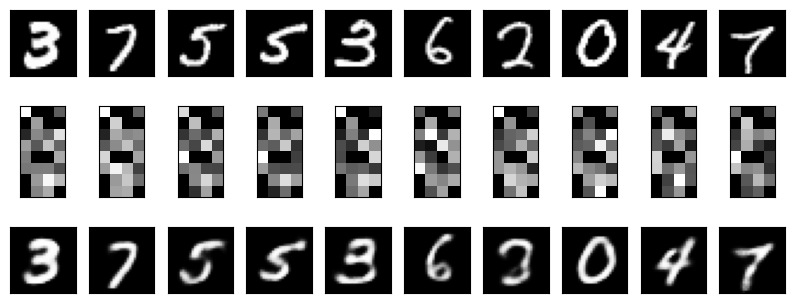

In [34]:
fig, axes = plt.subplots(nrows = 3, ncols = numero_imagens, figsize = (10, 4))
for imagens, ax_row in zip([imagens_teste, imagens_codificadas,
                            imagens_decodificadas], axes):
    for img, ax in zip(imagens, ax_row):
        ax.imshow(img, cmap = 'gray')
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

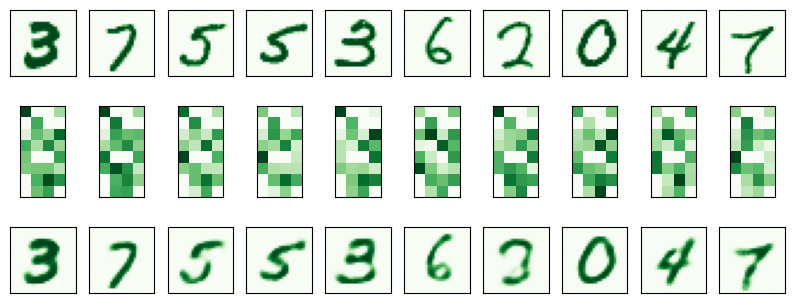

In [45]:
# 1. Preparando o 'quadro' (fig) e os 'espaços' (axes):
# nrows = 3: Teremos 3 linhas (Original, Código Comprimido, Reconstrução).
# ncols = numero_imagens: Teremos 10 colunas (uma para cada exemplo).
# figsize = (10, 4): Define o tamanho da janela do gráfico.
fig, axes = plt.subplots(nrows = 3, ncols = numero_imagens, figsize = (10, 4))

# 2. O grande loop de organização:
# zip([...], axes): Ele associa cada conjunto de dados a uma linha do gráfico.
# Linha 1: imagens_teste (Original)
# Linha 2: imagens_codificadas (O "resumo" de 32 números)
# Linha 3: imagens_decodificadas (O "xerox" final)
for imagens, ax_row in zip([imagens_teste, imagens_codificadas,
                            imagens_decodificadas], axes):
    
    # Loop interno: percorre cada imagem dentro da linha atual
    for img, ax in zip(imagens, ax_row):
        # Exibe a imagem em escala de cinza
        ax.imshow(img, cmap = 'Greens')
        
        # Remove os eixos (números de 0 a 28) para o visual ficar limpo
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

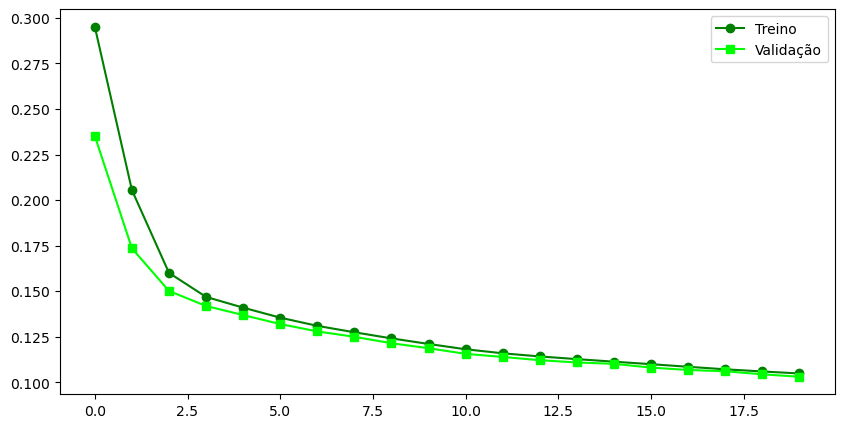

In [41]:
plt.figure(figsize=(10, 5))
# Mudando color para 'green' (verde)
plt.plot(historico_loss_train, label='Treino', color='green', marker='o') 
plt.plot(historico_loss_val, label='Validação', color='lime', marker='s') # Verde limão
plt.legend()
plt.show()

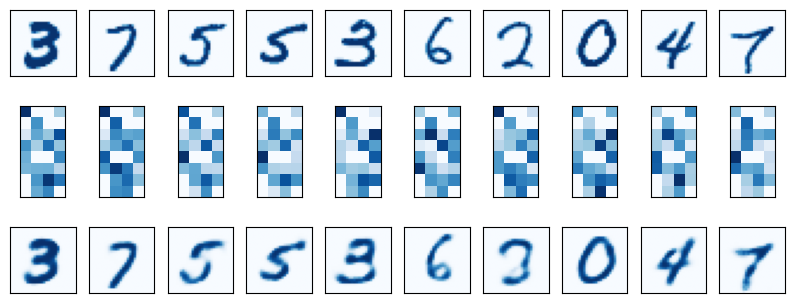

In [46]:
fig, axes = plt.subplots(nrows = 3, ncols = numero_imagens, figsize = (10, 4))
for imagens, ax_row in zip([imagens_teste, imagens_codificadas,
                            imagens_decodificadas], axes):
  for img, ax in zip(imagens, ax_row):
    # Mudando de 'gray' para 'Greens'
    ax.imshow(img, cmap = 'Blues') 
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)